# NB01 — Data Understanding
### Esercizio di predictive modelling sinistri (burning cost)

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style='whitegrid', palette='deep')

In [3]:
DATA_PATH = '../data/dataset_esercizio_pricing.xlsx'

## 1. Caricamento dati

In [4]:
xl = pd.ExcelFile(DATA_PATH)
print('Fogli disponibili:', xl.sheet_names)

Fogli disponibili: ['esposizione', 'sinistri']


In [5]:
esp = pd.read_excel(xl, 'esposizione')
sin = pd.read_excel(xl, 'sinistri')

print(f'esposizione: {esp.shape[0]:,} righe x {esp.shape[1]} colonne')
print(f'sinistri   : {sin.shape[0]:,} righe x {sin.shape[1]} colonne')

esposizione: 79,000 righe x 16 colonne
sinistri   : 40,192 righe x 5 colonne


Il file Excel contiene due tab:
- **esposizione** — una riga per assicurato per anno di copertura
- **sinistri** — una riga per singolo sinistro

## 2. Struttura e tipi

In [6]:
print('===== ESPOSIZIONE =====')
esp.info()

===== ESPOSIZIONE =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79000 entries, 0 to 78999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_assicurato        79000 non-null  int64  
 1   id_caponucleo        79000 non-null  int64  
 2   id_nucleo            79000 non-null  object 
 3   uy                   79000 non-null  int64  
 4   id_azienda           79000 non-null  object 
 5   settore              79000 non-null  object 
 6   tipo_assicurato      79000 non-null  object 
 7   legame_familiare     79000 non-null  object 
 8   carico_fiscale       79000 non-null  object 
 9   composizione_nucleo  79000 non-null  object 
 10  categoria            79000 non-null  object 
 11  eta                  79000 non-null  int64  
 12  sesso                79000 non-null  object 
 13  regione              79000 non-null  object 
 14  macroarea            79000 non-null  object 
 15  esposizione 

In [7]:
esp.head()

,id_assicurato,id_caponucleo,id_nucleo,uy,id_azienda,settore,tipo_assicurato,legame_familiare,carico_fiscale,composizione_nucleo,categoria,eta,sesso,regione,macroarea,esposizione
0,68440933,318440933,P013462,1,AZ141,INDUSTRIAL_MFG,FAMILIARE,CONIUGE,NON A CARICO,4,DIP_QUALIFICATO,43,M,Piemonte,NORD-OVEST,1.00
1,68440979,68440979,P008839,1,AZ032,INDUSTRIAL_MFG,CAPONUCLEO,CAPONUCLEO,CAPONUCLEO,1,ALTRO,32,M,Veneto,NORD-EST,1.00
2,68440982,68440982,P008788,1,AZ032,INDUSTRIAL_MFG,CAPONUCLEO,CAPONUCLEO,CAPONUCLEO,1,ALTRO,48,M,Veneto,NORD-EST,1.00
3,68440984,68440984,P008812,1,AZ032,INDUSTRIAL_MFG,CAPONUCLEO,CAPONUCLEO,CAPONUCLEO,1,ALTRO,29,M,Veneto,NORD-EST,0.44
4,68440999,68440999,P009752,1,AZ032,INDUSTRIAL_MFG,CAPONUCLEO,CAPONUCLEO,CAPONUCLEO,1,ALTRO,39,M,Veneto,NORD-EST,1.00


In [8]:
print('===== SINISTRI =====')
sin.info()

===== SINISTRI =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40192 entries, 0 to 40191
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id_sinistro    40192 non-null  object        
 1   id_assicurato  40192 non-null  int64         
 2   data_sinistro  40192 non-null  datetime64[ns]
 3   convenzione    40192 non-null  object        
 4   importo        40192 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.5+ MB


In [9]:
sin.head()

,id_sinistro,id_assicurato,data_sinistro,convenzione,importo
0,C0000001,1074707724,2017-01-01,N,34.0
1,C0000002,68444749,2017-01-02,Y,115.2
2,C0000003,818444486,2017-01-02,Y,0.0
3,C0000004,324707715,2017-01-02,Y,68.0
4,C0000005,1327359150,2017-01-02,N,28.0


## 3. Qualità dei dati

In [10]:
print('Missing values - esposizione:')
print(esp.isna().sum()[esp.isna().sum() > 0] if esp.isna().any().any() else '  nessuno')
print('\nMissing values - sinistri:')
print(sin.isna().sum()[sin.isna().sum() > 0] if sin.isna().any().any() else '  nessuno')

Missing values - esposizione:
  nessuno

Missing values - sinistri:
  nessuno


In [11]:
# Duplicati
print('Righe duplicate (esposizione):', esp.duplicated().sum())
print('Righe duplicate (sinistri)   :', sin.duplicated().sum())
print('id_sinistro duplicati        :', sin['id_sinistro'].duplicated().sum())
print('  -> id_sinistro univoci:', sin['id_sinistro'].nunique())
print('id_assicurato duplicati in esposizione:', esp['id_assicurato'].duplicated().sum())
print('  -> id_assicurato univoci:', esp['id_assicurato'].nunique())

Righe duplicate (esposizione): 0
Righe duplicate (sinistri)   : 0
id_sinistro duplicati        : 0
  -> id_sinistro univoci: 40192
id_assicurato duplicati in esposizione: 0
  -> id_assicurato univoci: 79000


La struttura della tab esposizione è confermata: una riga = un assicurato in un dato anno.
Non ci sono missing né duplicati: dataset già pulito a livello strutturale.

### 3.1 Anomalie sulla variabile **esposizione**

count    79000.000000
mean         0.953443
std          0.163892
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.010000
Name: esposizione, dtype: float64

esposizione (=0) : 36   (burning cost non definito)
esposizione (>1) : 8


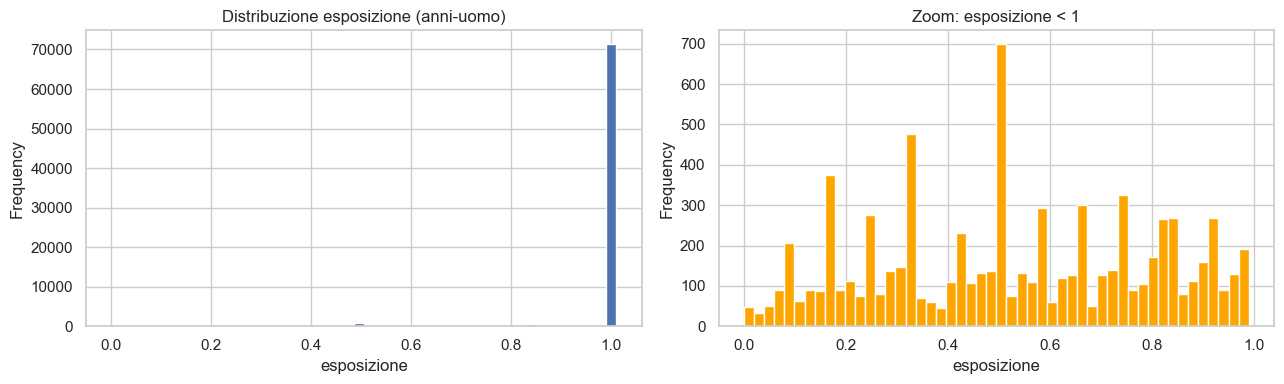

In [12]:
print(esp['esposizione'].describe())
print('\nesposizione (=0) :', (esp['esposizione'] == 0).sum(), '  (burning cost non definito)')
print('esposizione (>1) :', (esp['esposizione'] > 1).sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
esp['esposizione'].plot.hist(bins=50, ax=ax[0], edgecolor='white')
ax[0].set_title('Distribuzione esposizione (anni-uomo)'); ax[0].set_xlabel('esposizione')
esp.loc[esp['esposizione'] < 1, 'esposizione'].plot.hist(bins=50, ax=ax[1], edgecolor='white', color='orange')
ax[1].set_title('Zoom: esposizione < 1'); ax[1].set_xlabel('esposizione')
plt.tight_layout(); plt.show()

La maggior parte delle polizze ha esposizione = 1 (copertura per tutto l'anno). Due elementi da gestire:
- **36 righe con esposizione = 0**: il burning cost non è definito → andranno escluse dal target.
- **Valori leggermente > 1** (max 1.01): piccola anomalia di arrotondamento.

In [13]:
print(f"Esposizione = 1   : {(esp['esposizione'] == 1.0).mean():.2%}")
print(f"Esposizione = 0.5 : {(esp['esposizione']==0.5).mean():.2%}")

Esposizione = 1   : 90.10%
Esposizione = 0.5 : 0.86%


### 3.2 Anomalie sulla variabile importo

count    40192.000000
mean        92.072796
std         81.748776
min          0.000000
25%         54.000000
50%         76.500000
75%        104.000000
max       2570.800000
Name: importo, dtype: float64

importo == 0 : 427 (1.1%) -> prestazioni a costo nullo
importo  < 0 : 0


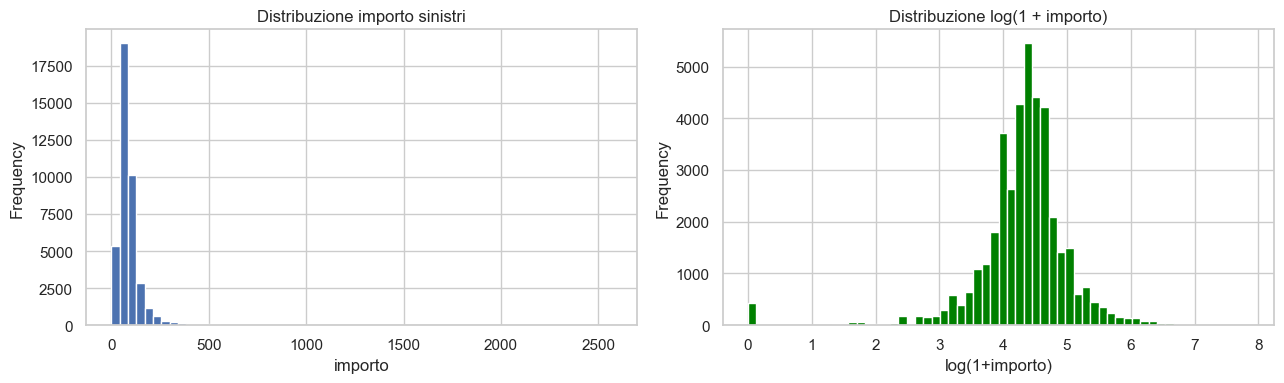

In [14]:
print(sin['importo'].describe())
print('\nimporto == 0 :', (sin['importo'] == 0).sum(), f"({(sin['importo']==0).mean():.1%})", '-> prestazioni a costo nullo')
print('importo  < 0 :', (sin['importo'] < 0).sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sin['importo'].plot.hist(bins=60, ax=ax[0], edgecolor='white')
ax[0].set_title('Distribuzione importo sinistri'); ax[0].set_xlabel('importo')
np.log1p(sin['importo']).plot.hist(bins=60, ax=ax[1], edgecolor='white', color='green')
ax[1].set_title('Distribuzione log(1 + importo)'); ax[1].set_xlabel('log(1+importo)')
plt.tight_layout(); plt.show()

La distribuzione degli importi è fortemente asimmetrica a destra (coda lunga): pochi sinistri
molto costosi, molti sinistri di importo contenuto. In scala logaritmica la forma è molto più regolare:
questo suggerisce una trasformazione logaritmica per il modello di severity. 
**427 sinistri (1,1%) hanno importo = 0**: prestazioni registrate ma senza costo a carico della compagnia.

### 3.3 Sinistri senza assicurato

In [15]:
# Quanti sinistri NON agganciano nessuna riga di esposizione?
join_check = sin.merge(esp[['id_assicurato']], on='id_assicurato', how='left', indicator=True)
orfani = (join_check['_merge'] == 'left_only').sum()
print(f'Sinistri senza match in esposizione: {orfani} su {len(sin)} ({orfani/len(sin):.2%})')
print('Importo complessivo dei sinistri senza match:', sin.loc[join_check["_merge"].values == "left_only", "importo"].sum())

Sinistri senza match in esposizione: 52 su 40192 (0.13%)
Importo complessivo dei sinistri senza match: 4722.65


**52 sinistri (0,13%)** non agganciano alcuna riga di esposizione. Sono una quota marginale:
verranno esclusi dal calcolo del target (non hanno un assicurato-anno a cui attribuire il costo).

## 4. Comprensione delle chiavi e della dimensione temporale

Punto delicato del dataset: id_assicurato e id_caponucleo **cambiano ogni anno**,
mentre id_nucleo è **stabile**. Quindi l'unico modo per ricostruire lo storico di un nucleo nel tempo è tramite id_nucleo.

In [16]:
# Distribuzione per anno di sottoscrizione
print('Righe per underwriting year (uy):')
print(esp['uy'].value_counts().sort_index())

Righe per underwriting year (uy):
uy
1    26158
2    28303
3    24539
Name: count, dtype: int64


In [17]:
# Quanti nuclei sono osservati su piu' anni?
nuclei_3anni = esp.groupby('id_nucleo')['uy'].nunique()
print('Nuclei osservati su anni distinti:')
print(nuclei_3anni.value_counts().sort_index())
print(f'\nTotale nuclei distinti: {esp["id_nucleo"].nunique()}')

Nuclei osservati su anni distinti:
uy
1    3561
2    4653
3    6484
Name: count, dtype: int64

Totale nuclei distinti: 14698


### 4.1 Relazione tra uy e data_sinistro

In [18]:
# Aggancio l'anno di sottoscrizione ai sinistri e guardo le date
sin_uy = sin.merge(esp[['id_assicurato', 'uy']], on='id_assicurato', how='inner')
print('Range date dei sinistri per anno di sottoscrizione (uy):')
print(sin_uy.groupby('uy')['data_sinistro'].agg(['min', 'max', 'count']))

Range date dei sinistri per anno di sottoscrizione (uy):
          min        max  count
uy                             
1  2017-01-01 2018-02-28  13413
2  2018-01-02 2019-06-06  14175
3  2019-01-02 2020-05-05  12552


**Conclusione chiave per la validazione temporale:** l'anno di sottoscrizione mappa sugli anni solari
**uy=1 → 2017, uy=2 → 2018, uy=3 → 2019**.

## 5. Analisi variabili

### 5.1 Anagrafica e attributi di polizza

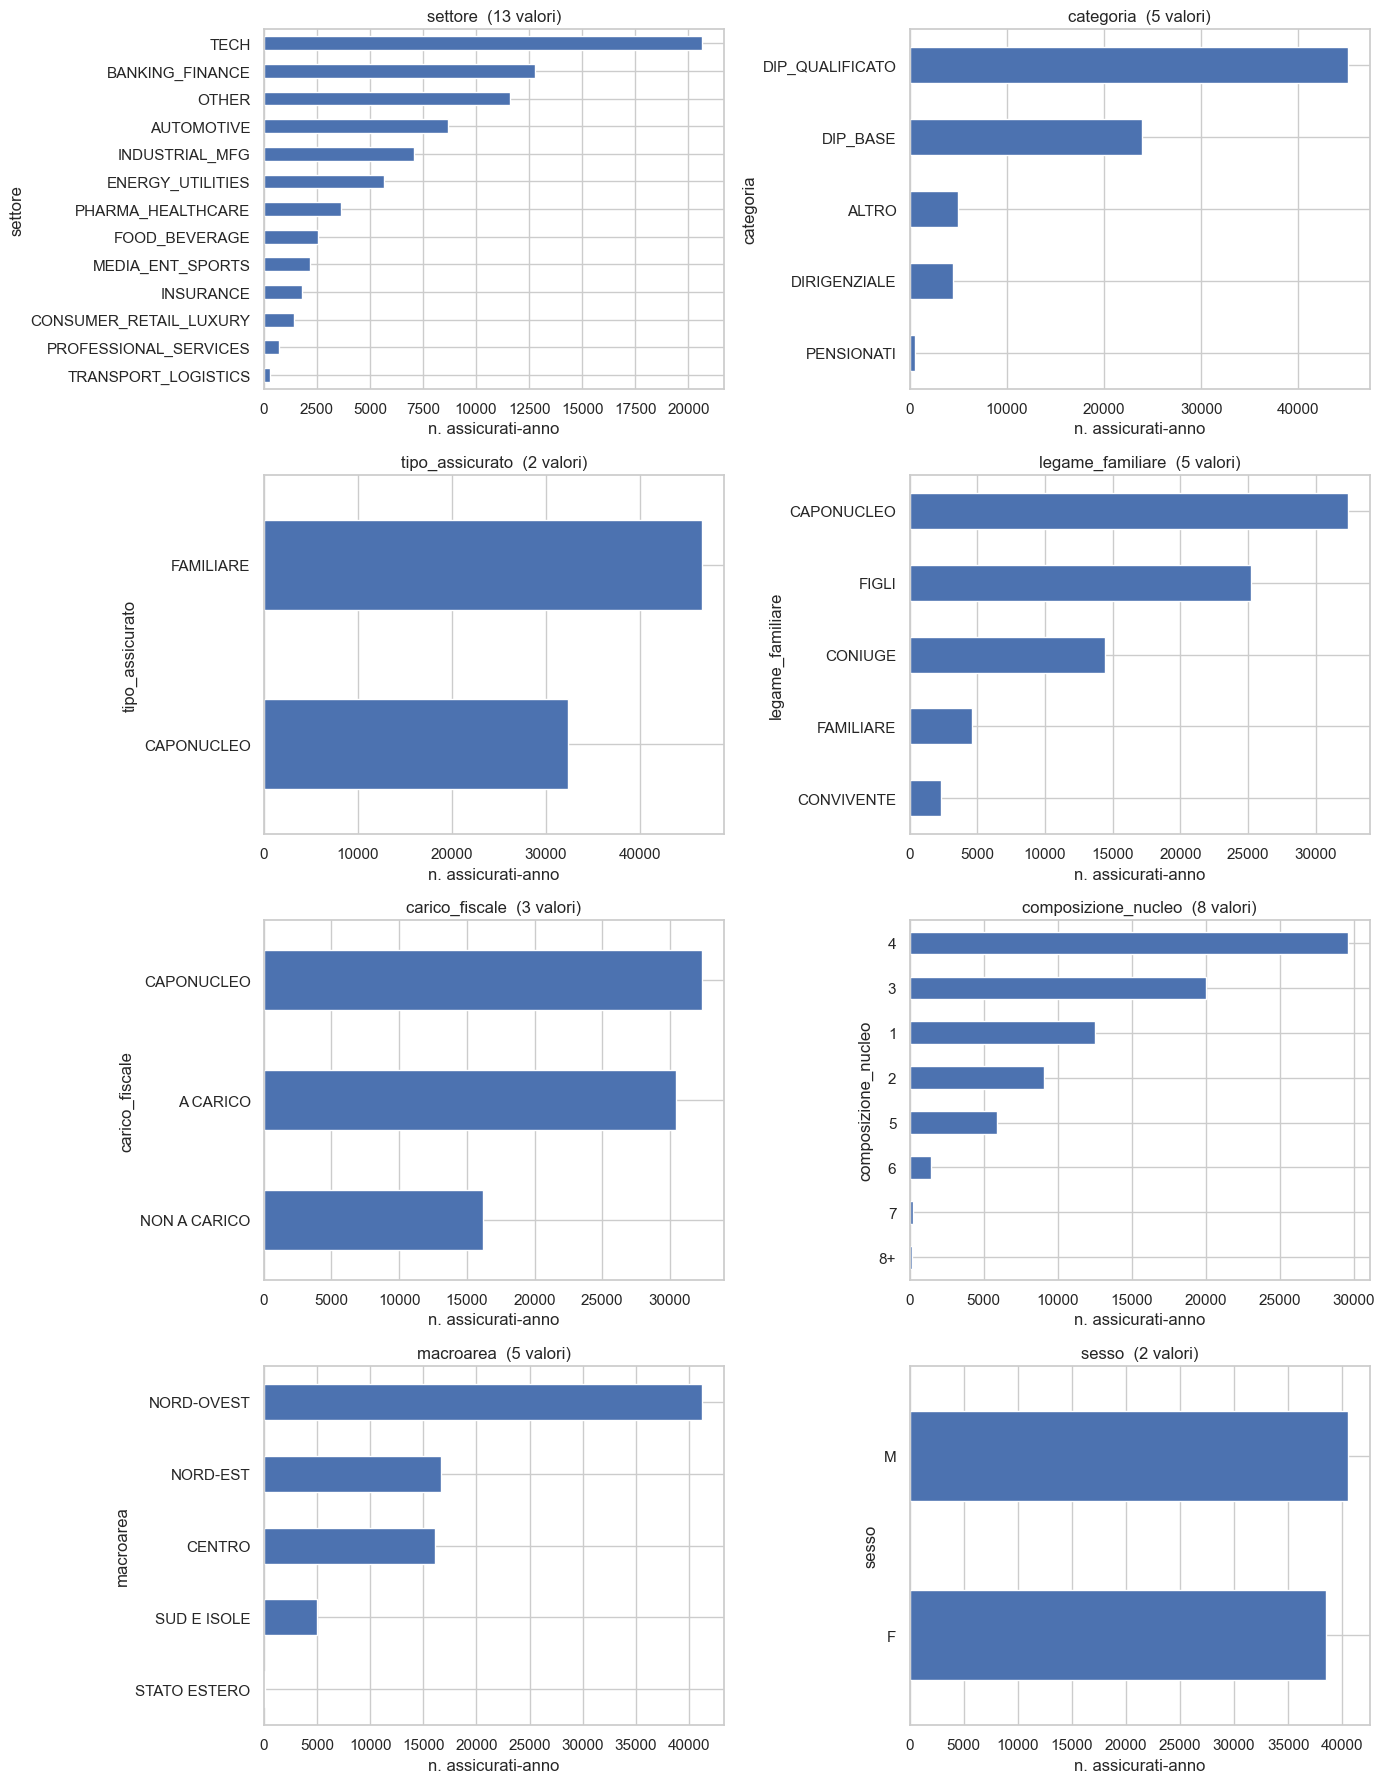

In [19]:
cat_cols = ['settore', 'categoria', 'tipo_assicurato', 'legame_familiare',
            'carico_fiscale', 'composizione_nucleo', 'macroarea', 'sesso']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, col in zip(axes.ravel(), cat_cols):
    vc = esp[col].astype(str).value_counts().sort_values()
    vc.plot.barh(ax=ax, edgecolor='white')
    ax.set_title(f'{col}  ({esp[col].nunique()} valori)')
    ax.set_xlabel('n. assicurati-anno')
plt.tight_layout(); plt.show()

In [20]:
# Regione: troppe categorie per il grafico sopra, la guardo a parte
print('Distribuzione per regione:')
print(esp['regione'].value_counts())
print('\nNumero di aziende distinte:', esp['id_azienda'].nunique())
print('Assicurati-anno per azienda:')
print(esp['id_azienda'].value_counts().describe())

Distribuzione per regione:
regione
Lombardia                28193
Lazio                    14348
Piemonte                 11873
Emilia-Romagna            9690
Veneto                    6338
Campania                  1651
Abruzzi                   1482
Toscana                   1315
Liguria                   1102
Puglia                     670
Sicilia                    635
Friuli-Venezia Giulia      514
Marche                     271
Calabria                   194
Sardegna                   186
Umbria                     161
STATO ESTERO               109
Basilicata                 105
Trentino-Alto Adige         81
Molise                      48
Valle d'Aosta               34
Name: count, dtype: int64

Numero di aziende distinte: 402
Assicurati-anno per azienda:
count     402.000000
mean      196.517413
std       704.535163
min         1.000000
25%         8.000000
50%        19.000000
75%        70.750000
max      8314.000000
Name: count, dtype: float64


Osservazioni:
- **Settore** dominato da TECH, BANKING_FINANCE, OTHER, AUTOMOTIVE.
- **Categoria** del caponucleo: in prevalenza DIP_QUALIFICATO e DIP_BASE; piccola quota di PENSIONATI.
- Circa **40%** degli assicurati sono caponucleo, il resto familiari (figli, coniugi, conviventi).
- Forte concentrazione geografica nel **NORD-OVEST**; quota trascurabile di STATO ESTERO.

### 5.2 Età

count    79000.000000
mean        33.044304
std         18.106895
min          0.000000
25%         17.000000
50%         36.000000
75%         47.000000
max         92.000000
Name: eta, dtype: float64


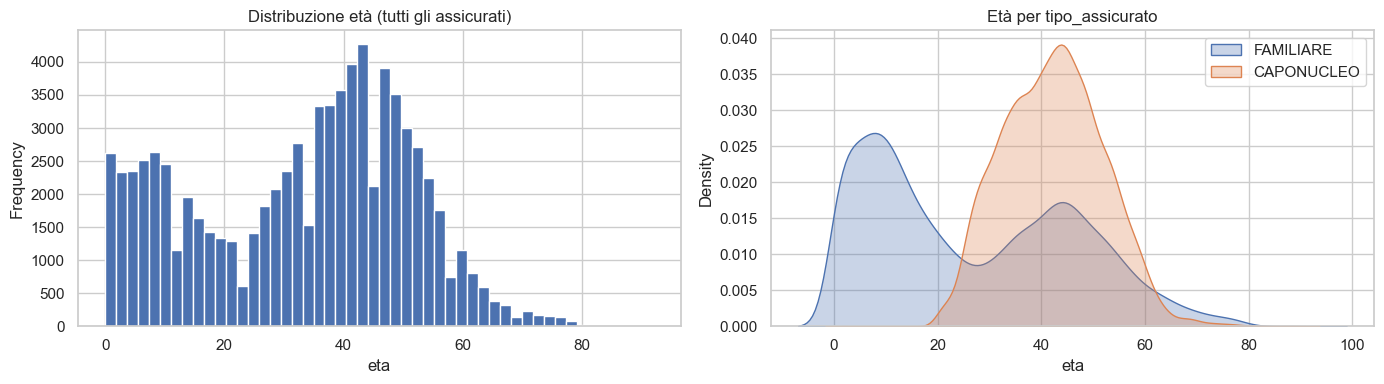

In [21]:
print(esp['eta'].describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
esp['eta'].plot.hist(bins=50, ax=ax[0], edgecolor='white')
ax[0].set_title('Distribuzione età (tutti gli assicurati)'); ax[0].set_xlabel('eta')

for tipo in esp['tipo_assicurato'].unique():
    sns.kdeplot(esp.loc[esp['tipo_assicurato'] == tipo, 'eta'], ax=ax[1], label=tipo, fill=True, alpha=.3)
ax[1].set_title('Età per tipo_assicurato'); ax[1].set_xlabel('eta'); ax[1].legend()
plt.tight_layout(); plt.show()

La popolazione include **neonati (età 0)** e anziani (fino a 92): coerente con un portafoglio che
copre il dipendente e i suoi familiari. I caponucleo si concentrano nelle età lavorative,
i familiari mostrano la componente dei figli e dei coniugi.

## 6. Analisi dei sinistri

### 6.1 Convenzione e importo

Sinistri per tipo di accesso (convenzione):
convenzione
N    24542
Y    15650
Name: count, dtype: int64

Statistiche importo per convenzione:
               count        mean   50%     max
convenzione                                   
N            24542.0  101.132349  79.0  2570.8
Y            15650.0   77.865796  76.5   707.2


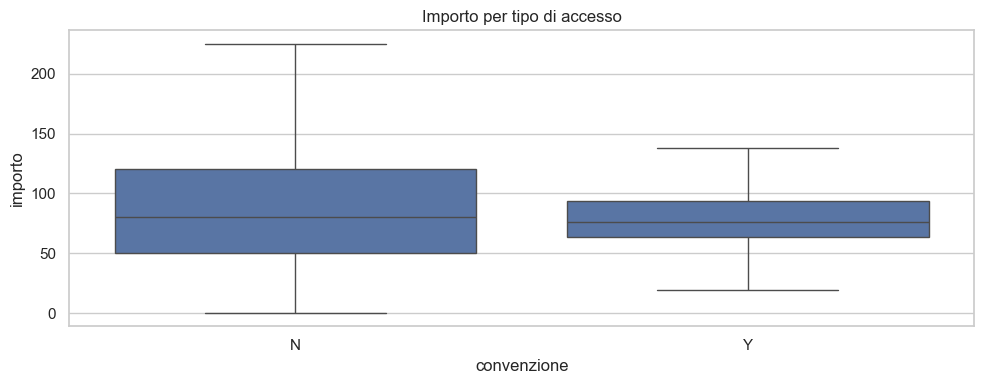

In [22]:
print('Sinistri per tipo di accesso (convenzione):')
print(sin['convenzione'].value_counts())
print('\nStatistiche importo per convenzione:')
print(sin.groupby('convenzione')['importo'].describe()[['count', 'mean', '50%', 'max']])

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=sin[sin['importo'] > 0], x='convenzione', y='importo', showfliers=False, ax=ax)
ax.set_title('Importo per tipo di accesso')
plt.tight_layout(); plt.show()

### 6.2 Andamento temporale dei sinistri

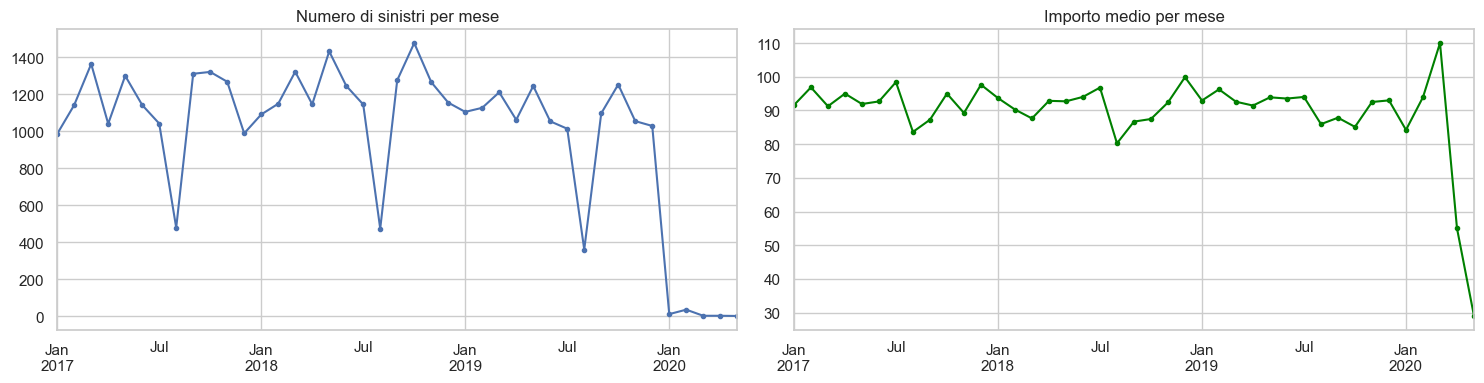

In [23]:
sin_ts = sin.set_index('data_sinistro').resample('MS').agg(
    n_sinistri=('id_sinistro', 'size'), importo_medio=('importo', 'mean'))

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sin_ts['n_sinistri'].plot(ax=ax[0], marker='.')
ax[0].set_title('Numero di sinistri per mese'); ax[0].set_xlabel('')
sin_ts['importo_medio'].plot(ax=ax[1], marker='.', color='green')
ax[1].set_title('Importo medio per mese'); ax[1].set_xlabel('')
plt.tight_layout(); plt.show()

## 7. Costruzione del target: burning cost

Aggrego i sinistri a livello di id_assicurato (= assicurato-anno) e li unisco all'esposizione.
Chi non ha sinistri ha costo e frequenza pari a 0.

$$\text{Frequenza} = \frac{n.\ sinistri}{esposizione}, \quad
\text{Severity} = \frac{costo}{n.\ sinistri}, \quad
\text{Burning cost} = \frac{costo}{esposizione} = Frequenza \times Severity$$

In [24]:
# Aggregazione sinistri per assicurato-anno
agg = sin.groupby('id_assicurato').agg(n_sinistri=('id_sinistro', 'size'), costo_totale=('importo', 'sum'))

base = esp.merge(agg, on='id_assicurato', how='left')
base[['n_sinistri', 'costo_totale']] = base[['n_sinistri', 'costo_totale']].fillna(0)

print('Righe totali:', len(base))
print('Sinistri attribuiti:', int(base['n_sinistri'].sum()), '(su', len(sin), 'totali; differenza = orfani)')

# Escludo le 36 righe con esposizione = 0 (target non definito)
n_zero_exp = (base['esposizione'] == 0).sum()
base = base[base['esposizione'] > 0].copy()
print(f'Escluse {n_zero_exp} righe con esposizione = 0 -> base modellabile: {len(base):,} righe')

base['frequenza'] = base['n_sinistri'] / base['esposizione']
base['severity'] = np.where(base['n_sinistri'] > 0, base['costo_totale'] / base['n_sinistri'], np.nan)
base['burning_cost'] = base['costo_totale'] / base['esposizione']
base[['n_sinistri', 'costo_totale', 'esposizione', 'frequenza', 'severity', 'burning_cost']].head()

Righe totali: 79000
Sinistri attribuiti: 40140 (su 40192 totali; differenza = orfani)
Escluse 36 righe con esposizione = 0 -> base modellabile: 78,964 righe


,n_sinistri,costo_totale,esposizione,frequenza,severity,burning_cost
0,2.0,200.9,1.00,2.0,100.45,200.9
1,0.0,0.0,1.00,0.0,NaN,0.0
2,1.0,82.1,1.00,1.0,82.10,82.1
3,0.0,0.0,0.44,0.0,NaN,0.0
4,0.0,0.0,1.00,0.0,NaN,0.0


### 7.1 Decomposizione e zero-inflation

In [25]:
quota_zero = (base['n_sinistri'] == 0).mean()
print(f"Assicurati SENZA sinistri : {(base['n_sinistri']==0).sum():,} ({quota_zero:.1%})")
print(f"Assicurati CON sinistri   : {(base['n_sinistri']>0).sum():,} ({1-quota_zero:.1%})")

print('\n--- Indicatori di portafoglio ---')
freq_ptf = base['n_sinistri'].sum() / base['esposizione'].sum()
sev_ptf = base['costo_totale'].sum() / base['n_sinistri'].sum()
bc_ptf = base['costo_totale'].sum() / base['esposizione'].sum()
print(f'Frequenza media di portafoglio : {freq_ptf:.3f} sinistri / anno-uomo')
print(f'Severity media di portafoglio  : {sev_ptf:,.2f} per sinistro')
print(f'Burning cost di portafoglio    : {bc_ptf:,.2f} per anno-uomo  (= {freq_ptf:.3f} x {sev_ptf:,.2f})')

print('\n--- Distribuzione n. sinistri (solo chi ne ha almeno 1) ---')
print(base.loc[base['n_sinistri'] > 0, 'n_sinistri'].describe()[['mean', '50%', 'max']])

Assicurati SENZA sinistri : 59,739 (75.7%)
Assicurati CON sinistri   : 19,225 (24.3%)

--- Indicatori di portafoglio ---
Frequenza media di portafoglio : 0.533 sinistri / anno-uomo
Severity media di portafoglio  : 92.07 per sinistro
Burning cost di portafoglio    : 49.07 per anno-uomo  (= 0.533 x 92.07)

--- Distribuzione n. sinistri (solo chi ne ha almeno 1) ---
mean     2.087906
50%      1.000000
max     29.000000
Name: n_sinistri, dtype: float64


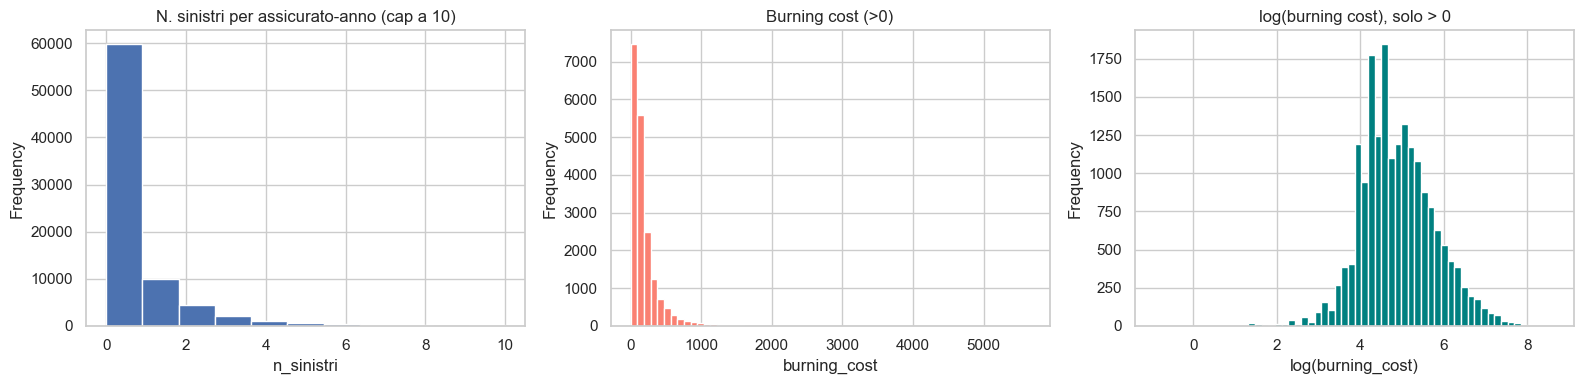

In [40]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
base['n_sinistri'].clip(upper=10).plot.hist(bins=11, ax=ax[0], edgecolor='white')
ax[0].set_title('N. sinistri per assicurato-anno (cap a 10)'); ax[0].set_xlabel('n_sinistri')

base.loc[base['burning_cost']>0, 'burning_cost'].plot.hist(bins=60, ax=ax[1], edgecolor='white', color='salmon')
ax[1].set_title('Burning cost (>0)'); ax[1].set_xlabel('burning_cost')

bc_pos = base.loc[base['burning_cost'] > 0, 'burning_cost']  
np.log(bc_pos).plot.hist(bins=60, ax=ax[2], edgecolor='white', color='teal') 
ax[2].set_title('log(burning cost), solo > 0'); ax[2].set_xlabel('log(burning_cost)')
plt.tight_layout(); plt.show()

In [41]:
base['burning_cost'].describe()

count    78964.000000
mean        48.518960
std        148.810051
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       5649.230769
Name: burning_cost, dtype: float64

**Struttura del target confermata:**
- **~76% di zeri** (assicurati-anno senza sinistri) → target fortemente zero-inflato.
- Tra chi ha sinistri, la maggioranza ne ha uno solo (mediana 1), ma la coda arriva a ~29.
- Il burning cost positivo è asimmetrico a destra; in scala log diventa molto più regolare.

Questa struttura (massa di zeri + coda positiva) è esattamente ciò che giustifica:
1. l'approccio **frequenza × severity** (due modelli separati), oppure
2. un singolo **GLM Tweedie** (compound Poisson-Gamma).

## 8. Analisi bivariata: i fattori di rischio

Per ogni fattore calcolo gli indicatori pesati per esposizione (modo attuarialmente corretto:
rapporto delle somme, non media dei rapporti individuali).

In [27]:
def rischio_per_gruppo(df, col, min_exp=50):
    "Frequenza, severity e burning cost per livello di una variabile, pesati per esposizione."
    g = (df.groupby(col, observed=True)
           .agg(esposizione=('esposizione', 'sum'),
                n_sinistri=('n_sinistri', 'sum'),
                costo=('costo_totale', 'sum'),
                n_polizze=('esposizione', 'size')))
    g['frequenza'] = g['n_sinistri'] / g['esposizione']
    g['severity'] = g['costo'] / g['n_sinistri'].replace(0, np.nan)
    g['burning_cost'] = g['costo'] / g['esposizione']
    g = g[g['esposizione'] >= min_exp]
    return g.sort_values('burning_cost', ascending=False)

In [28]:
# Fasce di eta per leggibilita'
base['fascia_eta'] = pd.cut(base['eta'], [-1, 17, 30, 45, 60, 75, 100],
                            labels=['0-17', '18-30', '31-45', '46-60', '61-75', '75+'])

rischio_per_gruppo(base, 'fascia_eta').style.format('{:,.3f}', subset=['frequenza', 'severity', 'burning_cost'])

,esposizione,n_sinistri,costo,n_polizze,frequenza,severity,burning_cost
fascia_eta,,,,,,,
75+,253.700000,269.000000,23734.710000,261,1.060,88.233,93.554
61-75,2625.340000,1904.000000,179233.750000,2775,0.725,94.135,68.271
46-60,18545.440000,11587.000000,1083784.960000,19022,0.625,93.535,58.439
31-45,24885.680000,14742.000000,1369980.400000,26159,0.592,92.930,55.051
18-30,9571.710000,3944.000000,357987.830000,10353,0.412,90.768,37.401
0-17,19440.150000,7694.000000,681145.510000,20394,0.396,88.529,35.038


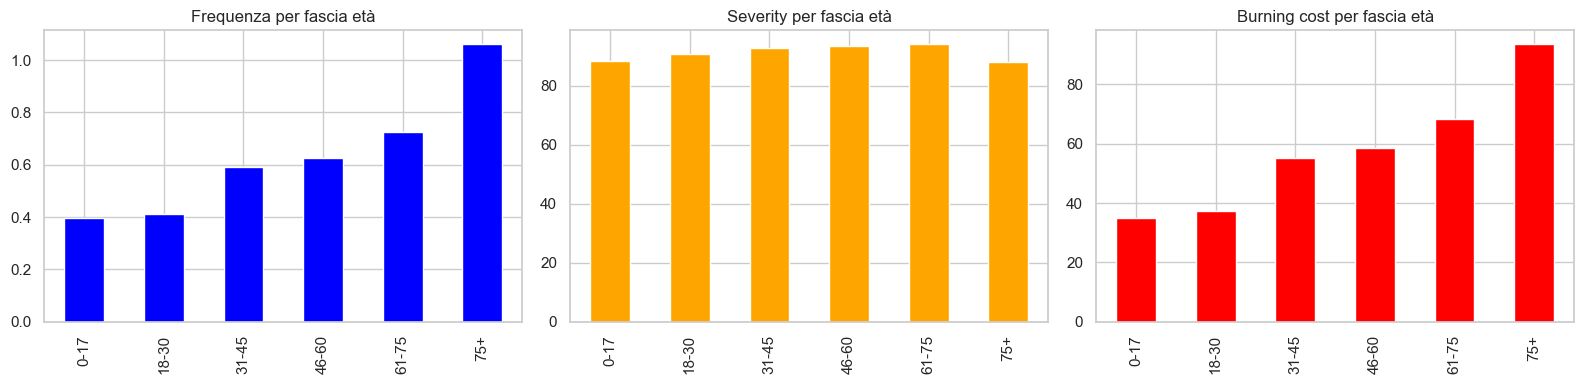

In [29]:
# Burning cost per eta: il driver tipicamente piu' forte in salute
g_eta = rischio_per_gruppo(base, 'fascia_eta').sort_index()
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
g_eta['frequenza'].plot.bar(ax=ax[0], color='blue'); ax[0].set_title('Frequenza per fascia età')
g_eta['severity'].plot.bar(ax=ax[1], color='orange'); ax[1].set_title('Severity per fascia età')
g_eta['burning_cost'].plot.bar(ax=ax[2], color='red'); ax[2].set_title('Burning cost per fascia età')
for a in ax: a.set_xlabel('')
plt.tight_layout(); plt.show()

In [30]:
for col in ['sesso', 'categoria', 'tipo_assicurato', 'legame_familiare', 'macroarea', 'settore','regione']:
    print(f'\n===== {col} =====')
    print(rischio_per_gruppo(base, col)[['n_polizze', 'frequenza', 'severity', 'burning_cost']].round(3))


===== sesso =====
       n_polizze  frequenza  severity  burning_cost
sesso                                              
F          38469      0.644    91.525        58.983
M          40495      0.427    92.864        39.635

===== categoria =====
                 n_polizze  frequenza  severity  burning_cost
categoria                                                    
PENSIONATI             583      1.537    97.906       150.469
DIRIGENZIALE          4492      0.886   109.301        96.883
DIP_QUALIFICATO      45057      0.650    92.472        60.143
DIP_BASE             23864      0.297    82.573        24.522
ALTRO                 4968      0.128    58.755         7.497

===== tipo_assicurato =====
                 n_polizze  frequenza  severity  burning_cost
tipo_assicurato                                              
CAPONUCLEO           32365      0.632    93.692        59.202
FAMILIARE            46599      0.464    90.546        42.032

===== legame_familiare =====
         

In [31]:
# Quota di sinistri in convenzione per assicurato -> possibile feature comportamentale
quota_conv = (sin.assign(is_conv=(sin['convenzione'] == 'Y').astype(int))
                 .groupby('id_assicurato')['is_conv'].mean()
                 .rename('quota_convenzione'))
tmp = base.merge(quota_conv, on='id_assicurato', how='left')
print('Severity media per chi usa prevalentemente la convenzione vs no (solo sinistrati):')
tmp_s = tmp[tmp['n_sinistri'] > 0].copy()
tmp_s['usa_conv'] = np.where(tmp_s['quota_convenzione'] >= 0.5, 'prev. convenzione', 'prev. libera scelta')
print(tmp_s.groupby('usa_conv')['severity'].agg(['count', 'mean', 'median']).round(2))

Severity media per chi usa prevalentemente la convenzione vs no (solo sinistrati):
                     count   mean  median
usa_conv                                 
prev. convenzione     8539  78.22    76.5
prev. libera scelta  10686  98.99    80.0


**Letture preliminari** (da confermare nei modelli):
- **L'età** è il driver atteso più forte: frequenza e burning cost crescono nelle fasce alte.
- Differenze per **sesso**, **categoria** contrattuale e **area geografica** plausibili e interpretabili.
- La **convenzione** sembra associata alla severity: utile come variabile comportamentale.
- Nessun fattore mostra separazioni implausibili → i dati sono coerenti col dominio.